In [28]:
import sys
from pathlib import Path
root_dir = Path('./notebook').resolve().parent.parent
sys.path.append(str(root_dir))

from scripts.util import db_connection
import pandas as pd

db = db_connection('../warehouse/instacart.duckdb')
print("Connected to DuckDB database successfully.")

Connected to DuckDB database successfully.


**Before you proceed please validate via terminal**
1. go run `python scripts/validate_database_schema.py`
2. go run `python scripts/validate_database_key_rs.py`

In [29]:
orders_by_day = db.sql("""
    select
        order_dow,
        count(distinct order_id) as order_count
    from fact_order_items
    group by order_dow
    order by order_dow
""").df()

**Quick view on the:**
1. order table
2. product table
3. department table

In [30]:
top_products = db.sql("""
    select
        p.product_name,
        count(*) as item_count,
        avg(f.reordered) as reorder_rate
    from fact_order_items f
    join dim_products p
        on f.product_id = p.product_id
    group by p.product_name
    order by item_count desc
    limit 20
""").df()

In [31]:
department_summary = db.sql("""
    select
        d.department_name,
        count(*) as item_count,
        avg(f.reordered) as reorder_rate
    from fact_order_items f
    join dim_departments d
        on f.department_id = d.department_id
    group by d.department_name
    order by item_count desc
""").df()

![features_engineer](../assets/instacart_feature_engineering_guide.svg)

## Business Insights: Macro to Micro

This section works from department-level totals down to individual products, then into order-timing and reorder-cadence behavior:

1. Top departments by items ordered and reordered items
2. Top departments — items ordered vs. reordered, combined into one clustered bar chart
3. Top items and reordered items within the top 5 departments
4. Order volume by department and day of week — a timing view for promotions
5. Average add-to-cart position by department (earlier vs. later adds)
6. Average add-to-cart position by product — top 10 earliest vs. top 10 latest
7. Basket size by day of week and by hour of day — does order timing correlate with how much people buy?
8. Average days since prior order, by department and by product (top 20 most-ordered, plus the bottom 20 and top 20 by repurchase cadence) — which items are popular and habitually rebought
9. Top 5 and bottom 5 products by % reordered (`reorder_count / total_count`)

**Data note:** this dataset has no prices, quantities, calendar dates, or customer demographics, so these are volume/behavior/timing metrics only, not revenue metrics.

In [32]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

BLUE = "#2a78d6"     # items ordered / earlier-added / below-median
ORANGE = "#eb6834"   # reordered items / later-added / above-median
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
BLUE_SEQUENTIAL = LinearSegmentedColormap.from_list(
    "blue_sequential", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
)


def _style_axes(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color(MUTED)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)


def bar_chart(x, y, color, title, xlabel, ylabel, value_fmt="{:,.0f}", rotate_x=0, figsize=None):
    figsize = figsize or (max(8, 0.4 * len(x)), 4.5)
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(x, y, color=color, width=0.6)

    ax.set_title(title, color=INK, fontsize=12, loc="left")
    ax.set_xlabel(xlabel, color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    _style_axes(ax)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

    if rotate_x:
        plt.setp(ax.get_xticklabels(), rotation=rotate_x, ha="right")

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            value_fmt.format(height),
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center", va="bottom", fontsize=9, color=INK,
        )

    plt.tight_layout()
    plt.show()


def grouped_bar_chart(labels, series, colors, title, xlabel, ylabel, value_fmt="{:,.0f}", rotate_x=45, figsize=None):
    """series: dict of {series_name: values-aligned-with-labels}. colors: dict of {series_name: color}."""
    n_series = len(series)
    figsize = figsize or (max(8, 0.7 * len(labels)), 4.5)
    fig, ax = plt.subplots(figsize=figsize)

    width = 0.8 / n_series
    x = range(len(labels))
    for i, (name, values) in enumerate(series.items()):
        offset = (i - (n_series - 1) / 2) * width
        positions = [xi + offset for xi in x]
        bars = ax.bar(positions, values, width=width, color=colors[name], label=name)
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                value_fmt.format(height),
                (bar.get_x() + bar.get_width() / 2, height),
                ha="center", va="bottom", fontsize=8, color=INK,
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_title(title, color=INK, fontsize=12, loc="left")
    ax.set_xlabel(xlabel, color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    _style_axes(ax)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

    if rotate_x:
        plt.setp(ax.get_xticklabels(), rotation=rotate_x, ha="right")

    ax.legend(frameon=False, loc="upper right")

    plt.tight_layout()
    plt.show()


def diverging_bar_chart(labels, values, colors, legend, title, xlabel, ylabel, value_fmt="{:,.1f}"):
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(labels))))
    bars = ax.barh(labels, values, color=colors, height=0.6)
    ax.invert_yaxis()

    ax.set_title(title, color=INK, fontsize=12, loc="left")
    ax.set_xlabel(xlabel, color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    _style_axes(ax)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            value_fmt.format(width),
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left", va="center", fontsize=9, color=INK,
        )

    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in legend.values()]
    ax.legend(handles, legend.keys(), frameon=False, loc="lower right")

    plt.tight_layout()
    plt.show()


def heatmap_chart(pivot_df, title, xlabel, ylabel, cbar_label):
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(pivot_df))))
    im = ax.imshow(pivot_df.values, cmap=BLUE_SEQUENTIAL, aspect="auto")

    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns, color=MUTED)
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index, color=MUTED)
    ax.set_title(title, color=INK, fontsize=12, loc="left")
    ax.set_xlabel(xlabel, color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, color=MUTED)
    cbar.ax.tick_params(colors=MUTED)

    plt.tight_layout()
    plt.show()

### 1. Top departments by items ordered and reordered items

No filtering here — with only ~21 departments total, every one fits on a single chart, so the full picture is shown before any cut is needed further down.

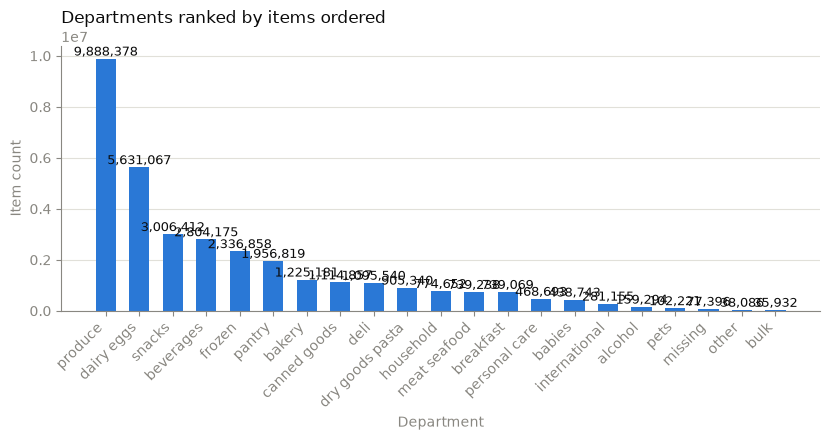

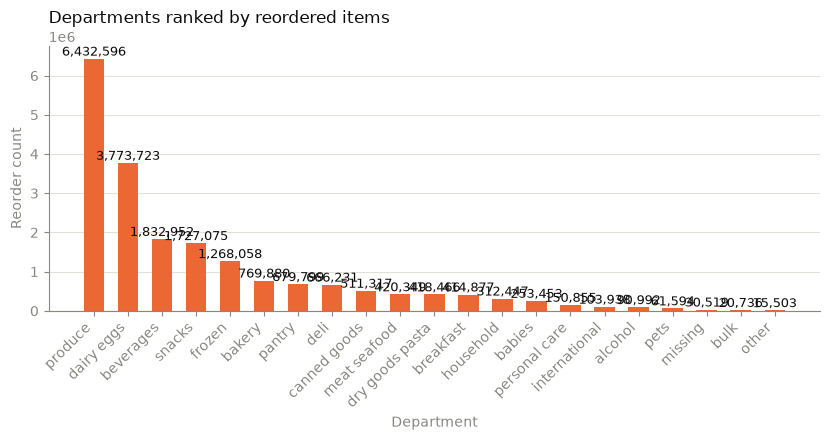

,department_name,item_count,reorder_count
0,produce,9888378,6432596.0
1,dairy eggs,5631067,3773723.0
2,snacks,3006412,1727075.0
3,beverages,2804175,1832952.0
4,frozen,2336858,1268058.0
5,pantry,1956819,679799.0
6,bakery,1225181,769880.0
7,canned goods,1114857,511317.0
8,deli,1095540,666231.0
9,dry goods pasta,905340,418466.0


In [33]:
dept_order_counts = db.sql("""
    select
        d.department_name,
        count(*) as item_count,
        sum(f.reordered) as reorder_count
    from fact_order_items f
    join dim_departments d
        on f.department_id = d.department_id
    group by d.department_name
    order by item_count desc
""").df()

bar_chart(
    dept_order_counts["department_name"],
    dept_order_counts["item_count"],
    color=BLUE,
    title="Departments ranked by items ordered",
    xlabel="Department",
    ylabel="Item count",
    rotate_x=45,
)

dept_by_reorder = dept_order_counts.sort_values("reorder_count", ascending=False)
bar_chart(
    dept_by_reorder["department_name"],
    dept_by_reorder["reorder_count"],
    color=ORANGE,
    title="Departments ranked by reordered items",
    xlabel="Department",
    ylabel="Reorder count",
    rotate_x=45,
)

dept_order_counts

### 2. Top departments — items ordered vs. reordered (clustered bar chart)

Reusing `dept_order_counts` from section 1, cut down to the top 10 of ~21 departments by item count: two bars per department start to crowd the chart past that point, and the top 10 already account for the large majority of order volume, so the tail adds clutter without adding insight.

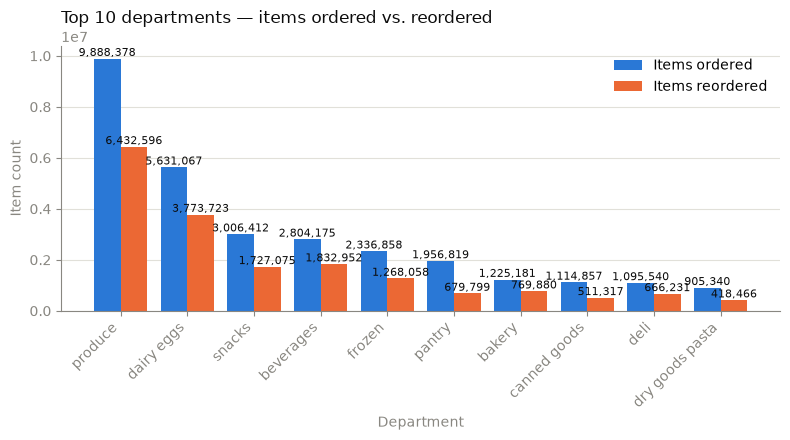

,department_name,item_count,reorder_count
0,produce,9888378,6432596.0
1,dairy eggs,5631067,3773723.0
2,snacks,3006412,1727075.0
3,beverages,2804175,1832952.0
4,frozen,2336858,1268058.0
5,pantry,1956819,679799.0
6,bakery,1225181,769880.0
7,canned goods,1114857,511317.0
8,deli,1095540,666231.0
9,dry goods pasta,905340,418466.0


In [34]:
top10_dept_counts = dept_order_counts.head(10)

grouped_bar_chart(
    top10_dept_counts["department_name"].tolist(),
    {
        "Items ordered": top10_dept_counts["item_count"].tolist(),
        "Items reordered": top10_dept_counts["reorder_count"].tolist(),
    },
    colors={"Items ordered": BLUE, "Items reordered": ORANGE},
    title="Top 10 departments — items ordered vs. reordered",
    xlabel="Department",
    ylabel="Item count",
    rotate_x=45,
)

top10_dept_counts

### 3. Top items and reordered items within the top 5 departments

Two cuts here: departments are cut from ~21 to the 5 with the most items ordered (the ones with enough volume to matter for merchandising decisions), and within each, products are cut to the top 5 by item count and top 5 by reorder count (out of ~50k products) — deep enough to name real items, shallow enough not to produce a wall of 21 x N charts.

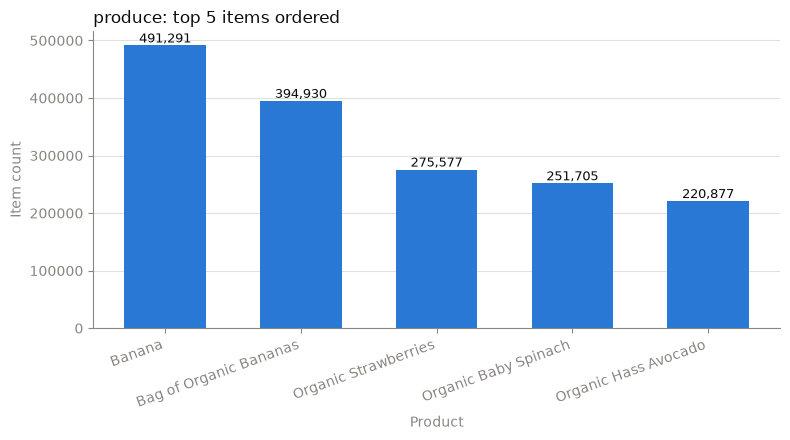

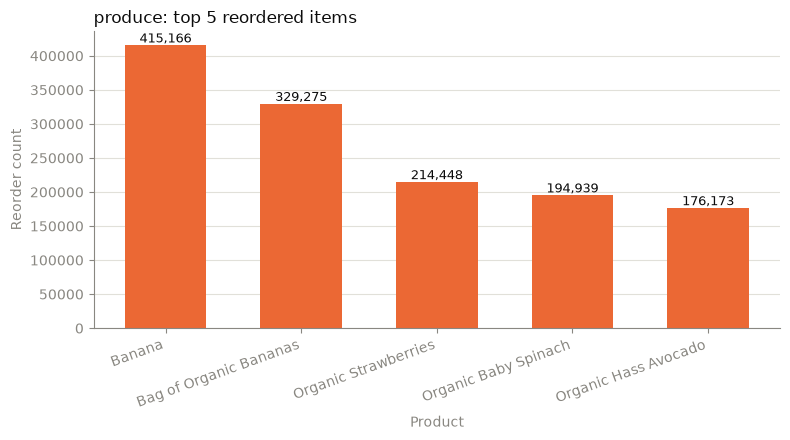

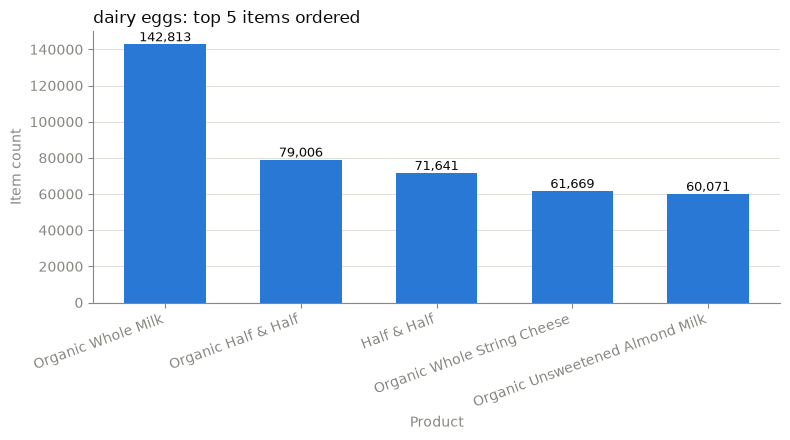

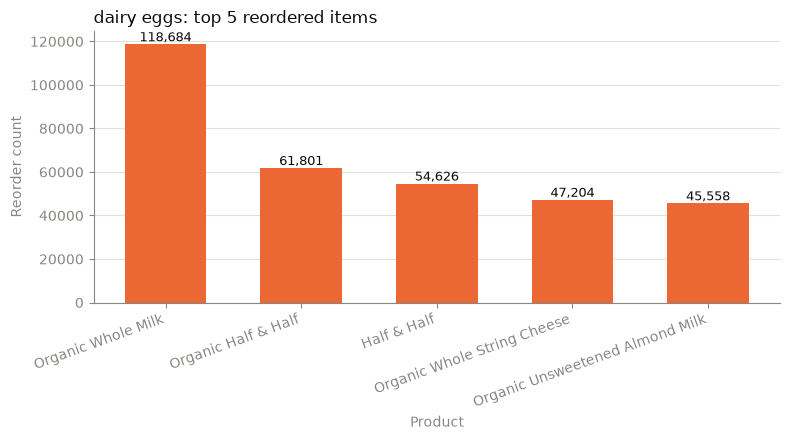

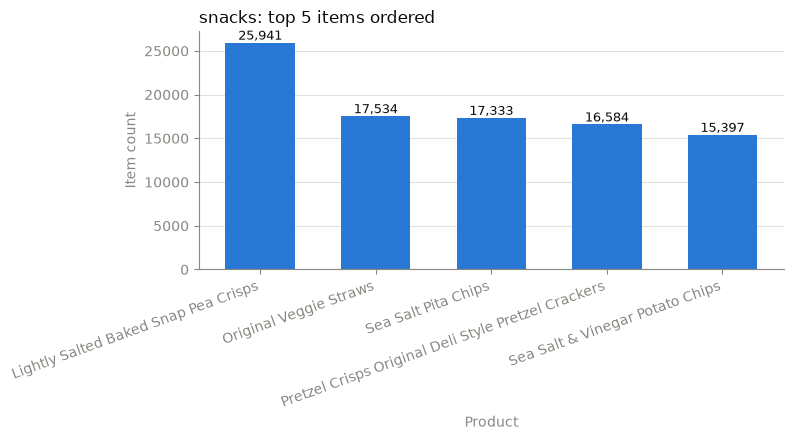

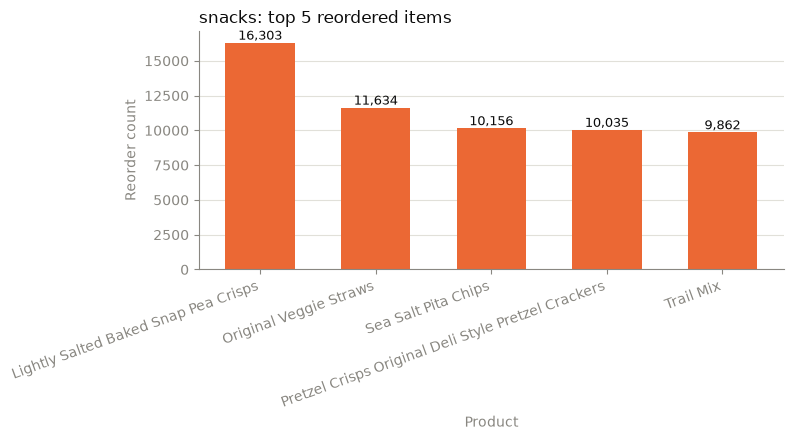

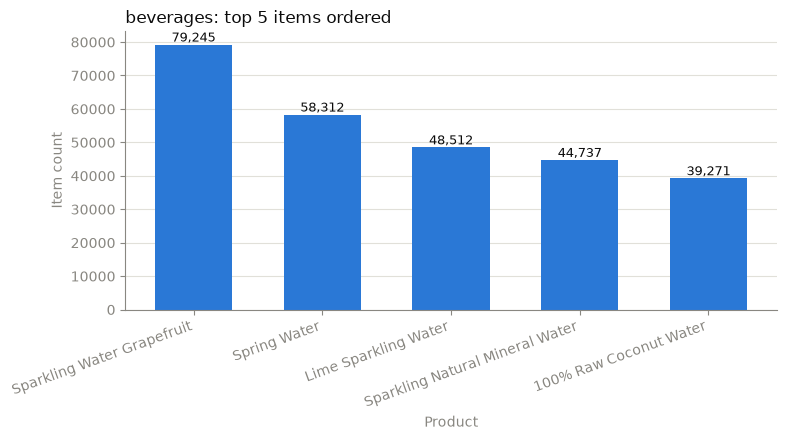

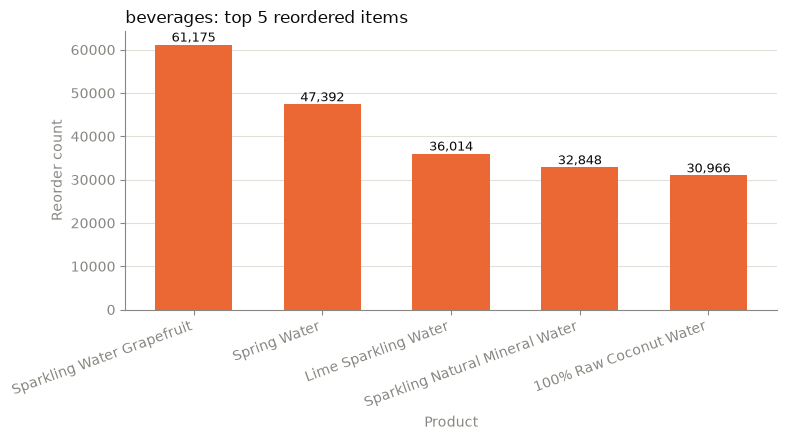

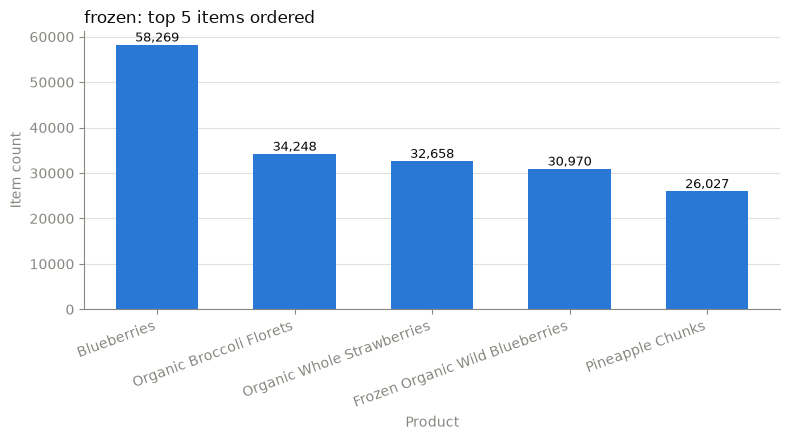

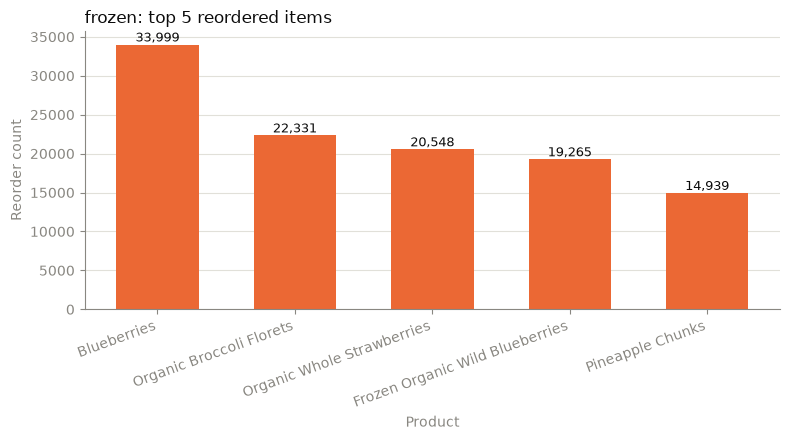

In [35]:
top5_departments = dept_order_counts["department_name"].head(5).tolist()
dept_list_sql = ", ".join(f"'{d}'" for d in top5_departments)

dept_product_agg = db.sql(f"""
    select
        d.department_name,
        p.product_name,
        count(*) as item_count,
        sum(f.reordered) as reorder_count
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    join dim_departments d on f.department_id = d.department_id
    where d.department_name in ({dept_list_sql})
    group by d.department_name, p.product_name
""").df()

for dept in top5_departments:
    dept_slice = dept_product_agg[dept_product_agg["department_name"] == dept]

    top_items = dept_slice.nlargest(5, "item_count")
    bar_chart(
        top_items["product_name"], top_items["item_count"],
        color=BLUE, title=f"{dept}: top 5 items ordered",
        xlabel="Product", ylabel="Item count", rotate_x=20,
    )

    top_reordered = dept_slice.nlargest(5, "reorder_count")
    bar_chart(
        top_reordered["product_name"], top_reordered["reorder_count"],
        color=ORANGE, title=f"{dept}: top 5 reordered items",
        xlabel="Product", ylabel="Reorder count", rotate_x=20,
    )

### 4. Order volume by department and day of week — timing for a sale

No cut applied — all ~21 departments and all 7 day codes fit in one heatmap, so nothing needs to be dropped to keep it readable.

**Data limitation:** `order_dow` is a numeric code (0–6) from the raw Instacart export. Instacart has not published an official mapping from this code to an actual weekday name, so results are reported by **code only** (e.g. "day code 0") rather than an invented weekday label.

Each row below is normalized to the % of that department's own items falling on each day, so departments can be compared on their *pattern* regardless of overall size — the darkest cell in a row marks that department's peak day code. A peak day shows where organic demand is already highest; whether a sale should reinforce that day or target a slower one is a business call this data can inform but not decide on its own.

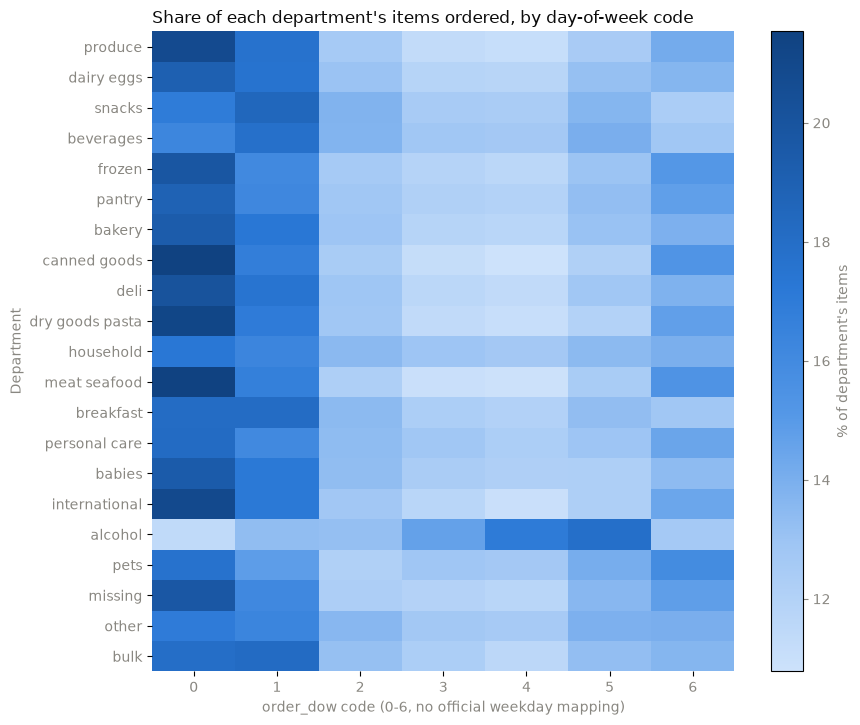

,department_name,peak_order_dow_code
16,alcohol,5
14,babies,0
6,bakery,0
3,beverages,1
12,breakfast,1
20,bulk,1
7,canned goods,0
1,dairy eggs,0
8,deli,0
9,dry goods pasta,0


In [36]:
dept_dow = db.sql("""
    select
        d.department_name,
        f.order_dow,
        count(*) as item_count
    from fact_order_items f
    join dim_departments d
        on f.department_id = d.department_id
    group by d.department_name, f.order_dow
""").df()

dept_dow_pivot = dept_dow.pivot(index="department_name", columns="order_dow", values="item_count").fillna(0)
dept_dow_pivot = dept_dow_pivot.loc[dept_dow_pivot.sum(axis=1).sort_values(ascending=False).index]
dept_dow_share = dept_dow_pivot.div(dept_dow_pivot.sum(axis=1), axis=0) * 100

heatmap_chart(
    dept_dow_share,
    title="Share of each department's items ordered, by day-of-week code",
    xlabel="order_dow code (0-6, no official weekday mapping)",
    ylabel="Department",
    cbar_label="% of department's items",
)

peak_day_by_department = (
    dept_dow_pivot.idxmax(axis=1)
    .rename("peak_order_dow_code")
    .reset_index()
    .sort_values("department_name")
)
peak_day_by_department

### 5. Add-to-cart timing by department

No cut applied — every department is shown; at ~21 rows a diverging bar chart stays readable without needing one. Average `add_to_cart_order` per department — a lower number means items from that department tend to be dropped into the basket earlier in the shopping trip.

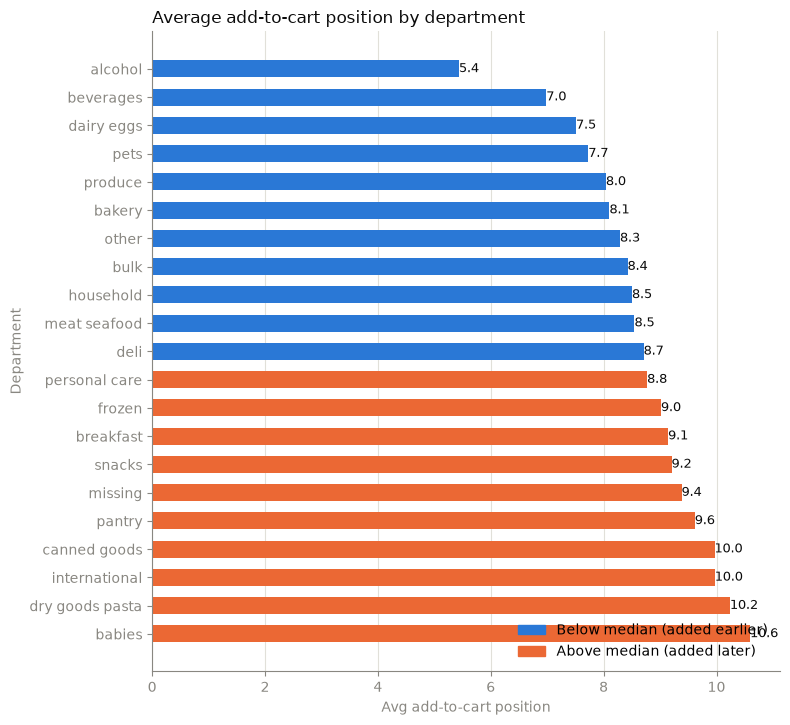

,department_name,avg_add_to_cart_order,item_count
0,alcohol,5.435961,159294
1,beverages,6.983270,2804175
2,dairy eggs,7.510144,5631067
3,pets,7.728285,102221
4,produce,8.039761,9888378
5,bakery,8.102459,1225181
6,other,8.288978,38086
7,bulk,8.423244,35932
8,household,8.501856,774652
9,meat seafood,8.546390,739238


In [37]:
dept_atc = db.sql("""
    select
        d.department_name,
        avg(f.add_to_cart_order) as avg_add_to_cart_order,
        count(*) as item_count
    from fact_order_items f
    join dim_departments d
        on f.department_id = d.department_id
    group by d.department_name
    order by avg_add_to_cart_order
""").df()

overall_median_atc = dept_atc["avg_add_to_cart_order"].median()
dept_atc_colors = [BLUE if v <= overall_median_atc else ORANGE for v in dept_atc["avg_add_to_cart_order"]]

diverging_bar_chart(
    dept_atc["department_name"],
    dept_atc["avg_add_to_cart_order"],
    dept_atc_colors,
    legend={"Below median (added earlier)": BLUE, "Above median (added later)": ORANGE},
    title="Average add-to-cart position by department",
    xlabel="Avg add-to-cart position",
    ylabel="Department",
)

dept_atc

### 6. Add-to-cart timing by product

Same question at the product level, limited to the 10 products added earliest and 10 added latest on average (out of ~50k products) to keep the chart readable. `item_count` is shown alongside each average so low-volume products (whose average can be noisy) are visible rather than hidden.

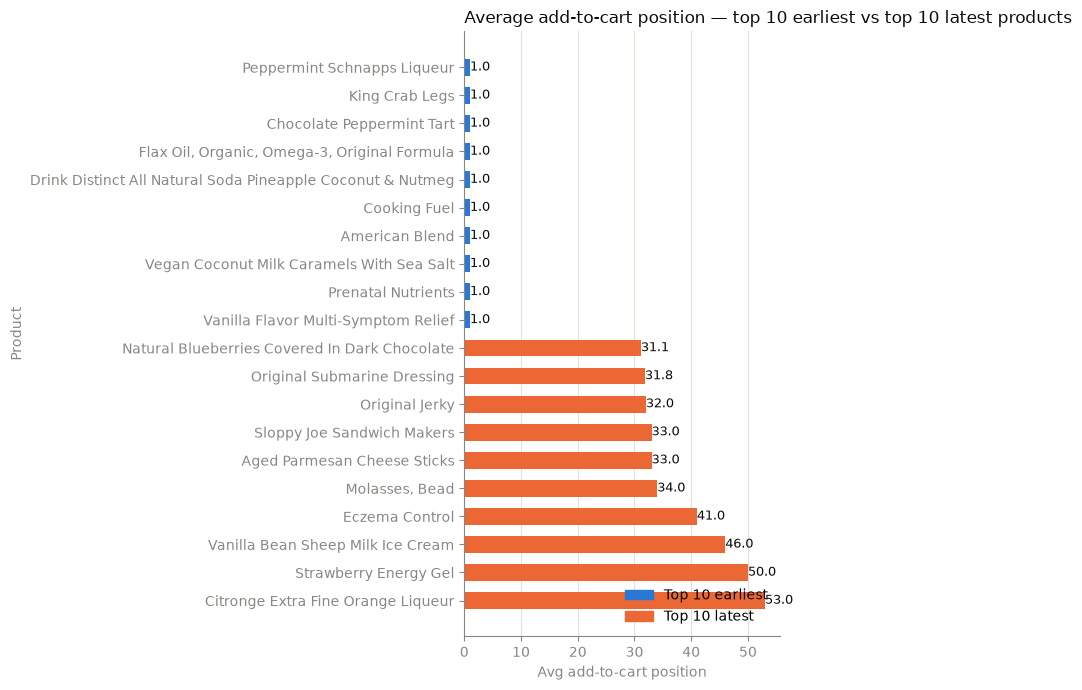

,product_name,avg_add_to_cart_order,item_count,group
0,Peppermint Schnapps Liqueur,1.000000,3,earliest
1,King Crab Legs,1.000000,3,earliest
2,Chocolate Peppermint Tart,1.000000,1,earliest
3,"Flax Oil, Organic, Omega-3, Original Formula",1.000000,1,earliest
4,Drink Distinct All Natural Soda Pineapple Coco...,1.000000,1,earliest
5,Cooking Fuel,1.000000,7,earliest
6,American Blend,1.000000,2,earliest
7,Vegan Coconut Milk Caramels With Sea Salt,1.000000,1,earliest
8,Prenatal Nutrients,1.000000,2,earliest
9,Vanilla Flavor Multi-Symptom Relief,1.000000,3,earliest


In [38]:
product_atc_earliest = db.sql("""
    select
        p.product_name,
        avg(f.add_to_cart_order) as avg_add_to_cart_order,
        count(*) as item_count
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    group by p.product_name
    order by avg_add_to_cart_order asc
    limit 10
""").df()

product_atc_latest = db.sql("""
    select
        p.product_name,
        avg(f.add_to_cart_order) as avg_add_to_cart_order,
        count(*) as item_count
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    group by p.product_name
    order by avg_add_to_cart_order desc
    limit 10
""").df()

product_atc_earliest["group"] = "earliest"
product_atc_latest["group"] = "latest"
product_atc_combined = pd.concat([product_atc_earliest, product_atc_latest]).sort_values(
    "avg_add_to_cart_order"
)
product_atc_colors = [BLUE if g == "earliest" else ORANGE for g in product_atc_combined["group"]]

diverging_bar_chart(
    product_atc_combined["product_name"],
    product_atc_combined["avg_add_to_cart_order"],
    product_atc_colors,
    legend={"Top 10 earliest": BLUE, "Top 10 latest": ORANGE},
    title="Average add-to-cart position — top 10 earliest vs top 10 latest products",
    xlabel="Avg add-to-cart position",
    ylabel="Product",
)

product_atc_combined[["product_name", "avg_add_to_cart_order", "item_count", "group"]]

### 7. Basket size by day of week and by hour of day

No cut applied — the day-of-week and hour-of-day domains are already small and fixed (7 codes, 24 hours), so every value is shown. Basket size = items per order (`count(*)` per `order_id`). Averaged across all orders falling on each day code / hour, this shows whether *when* someone shops correlates with *how much* they buy.

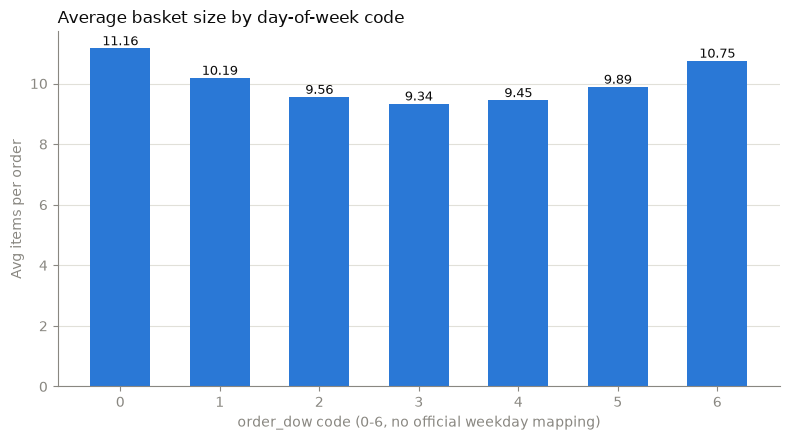

,order_dow,avg_basket_size,order_count
0,0,11.164181,585237
1,1,10.187488,576377
2,2,9.558194,458074
3,3,9.340386,428087
4,4,9.451031,417171
5,5,9.893012,443388
6,6,10.754069,437749


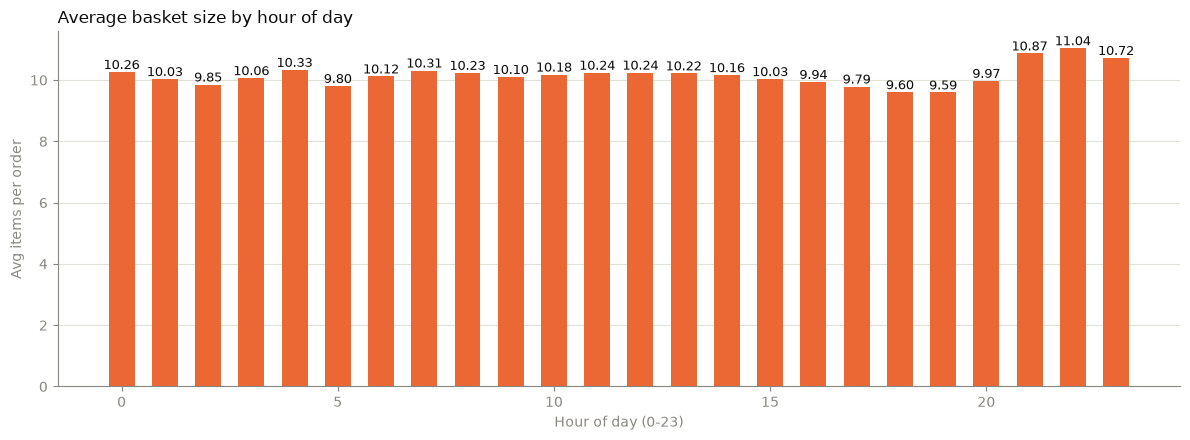

,order_hour_of_day,avg_basket_size,order_count
0,0,10.260574,22224
1,1,10.031562,12103
2,2,9.852203,7375
3,3,10.061576,5343
4,4,10.330799,5393
5,5,9.804672,9374
6,6,10.117407,29913
7,7,10.310101,90032
8,8,10.233128,174664
9,9,10.100103,252529


In [39]:
basket_by_dow = db.sql("""
    with basket as (
        select order_id, order_dow, count(*) as basket_size
        from fact_order_items
        group by order_id, order_dow
    )
    select order_dow, avg(basket_size) as avg_basket_size, count(*) as order_count
    from basket
    group by order_dow
    order by order_dow
""").df()

bar_chart(
    basket_by_dow["order_dow"],
    basket_by_dow["avg_basket_size"],
    color=BLUE,
    title="Average basket size by day-of-week code",
    xlabel="order_dow code (0-6, no official weekday mapping)",
    ylabel="Avg items per order",
    value_fmt="{:,.2f}",
)

display(basket_by_dow)

basket_by_hour = db.sql("""
    with basket as (
        select order_id, order_hour_of_day, count(*) as basket_size
        from fact_order_items
        group by order_id, order_hour_of_day
    )
    select order_hour_of_day, avg(basket_size) as avg_basket_size, count(*) as order_count
    from basket
    group by order_hour_of_day
    order by order_hour_of_day
""").df()

bar_chart(
    basket_by_hour["order_hour_of_day"],
    basket_by_hour["avg_basket_size"],
    color=ORANGE,
    title="Average basket size by hour of day",
    xlabel="Hour of day (0-23)",
    ylabel="Avg items per order",
    value_fmt="{:,.2f}",
    figsize=(12, 4.5),
)

basket_by_hour

### 8. Average days since prior order — by department and by product

**Data note:** `days_since_prior_order` describes the *order*, not the product — it's the gap since that customer's previous order (any items). Averaging it over the orders that contain a given department/product is a proxy for how often its buyers shop overall, not proof that the item itself was rebought on that cadence. A **lower** average means the item's typical buyer is a frequent, short-cycle shopper — read together with `item_count` (popularity) and reorder rate, that combination is what marks an item as both popular and habitually rebought.

The department-level chart below applies no cut — all ~21 departments are shown. The product-level charts that follow do need cuts (out of ~50k products), each explained where it happens.

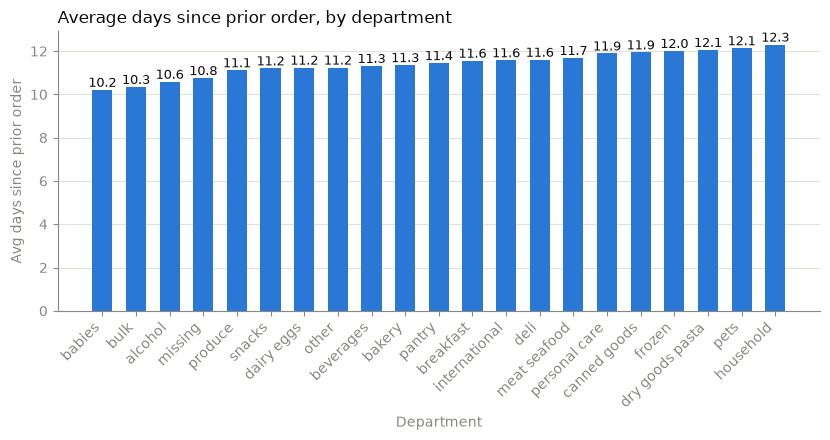

,department_name,avg_days_since_prior,item_count
0,babies,10.210183,438743
1,bulk,10.340874,35932
2,alcohol,10.580966,159294
3,missing,10.751191,77396
4,produce,11.112160,9888378
5,snacks,11.200179,3006412
6,dairy eggs,11.233251,5631067
7,other,11.235582,38086
8,beverages,11.310726,2804175
9,bakery,11.349486,1225181


In [40]:
dept_days_since_prior = db.sql("""
    select
        d.department_name,
        avg(f.days_since_prior_order) as avg_days_since_prior,
        count(*) as item_count
    from fact_order_items f
    join dim_departments d
        on f.department_id = d.department_id
    group by d.department_name
    order by avg_days_since_prior asc
""").df()

bar_chart(
    dept_days_since_prior["department_name"],
    dept_days_since_prior["avg_days_since_prior"],
    color=BLUE,
    title="Average days since prior order, by department",
    xlabel="Department",
    ylabel="Avg days since prior order",
    value_fmt="{:,.1f}",
    rotate_x=45,
)

dept_days_since_prior

**Top 20 most-ordered products, by average days since prior order.** First cut: out of ~50k products, this narrows to the 20 with the highest raw item_count — the products already known (from the earlier ranking) to be the most popular — and asks whether that popularity also comes with a tight repurchase cadence. No minimum-order threshold is needed here since these are by construction the highest-volume products.

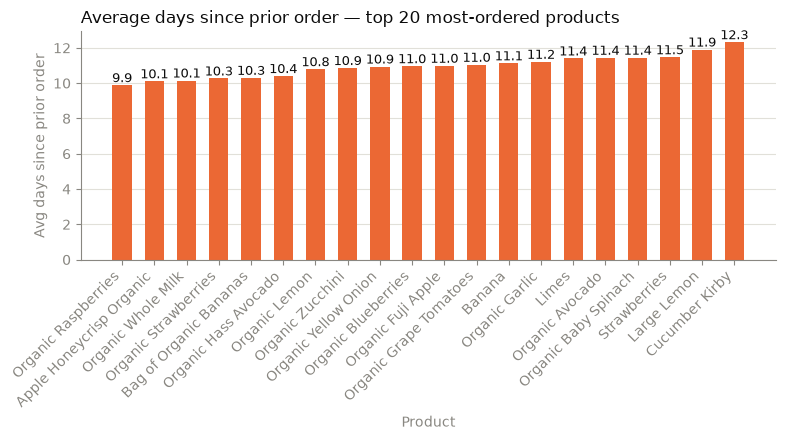

,product_name,item_count,avg_days_since_prior
10,Organic Raspberries,142603,9.885255
19,Apple Honeycrisp Organic,87272,10.105405
9,Organic Whole Milk,142813,10.149259
2,Organic Strawberries,275577,10.264568
1,Bag of Organic Bananas,394930,10.298466
4,Organic Hass Avocado,220877,10.401271
17,Organic Lemon,91251,10.791511
13,Organic Zucchini,109412,10.855514
11,Organic Yellow Onion,117716,10.940235
14,Organic Blueberries,105026,10.960725


In [41]:
product_days_since_prior = db.sql("""
    select
        p.product_name,
        count(*) as item_count,
        avg(f.days_since_prior_order) as avg_days_since_prior
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    group by p.product_name
    order by item_count desc
    limit 20
""").df().sort_values("avg_days_since_prior")

bar_chart(
    product_days_since_prior["product_name"],
    product_days_since_prior["avg_days_since_prior"],
    color=ORANGE,
    title="Average days since prior order — top 20 most-ordered products",
    xlabel="Product",
    ylabel="Avg days since prior order",
    value_fmt="{:,.1f}",
    rotate_x=45,
)

product_days_since_prior[["product_name", "item_count", "avg_days_since_prior"]]

**Bottom 20 by average days since prior order** — a different cut from the chart above: instead of pre-filtering to the top-20-by-volume, this ranks *all* products by `avg_days_since_prior` and takes the 20 lowest. A `count(*) >= 1,000` floor is applied first so the ranking isn't won by a handful of one-off purchases with a freak-low average; 1,000 was picked as comfortably above the median product's order count (~63) while still leaving thousands of qualifying products to rank. Kept at 20 (matching the top-20-by-volume chart above) so the two are visually comparable. These are the products whose buyers are on the shortest repurchase cycle, i.e. most consistently rebought soon after a previous order.

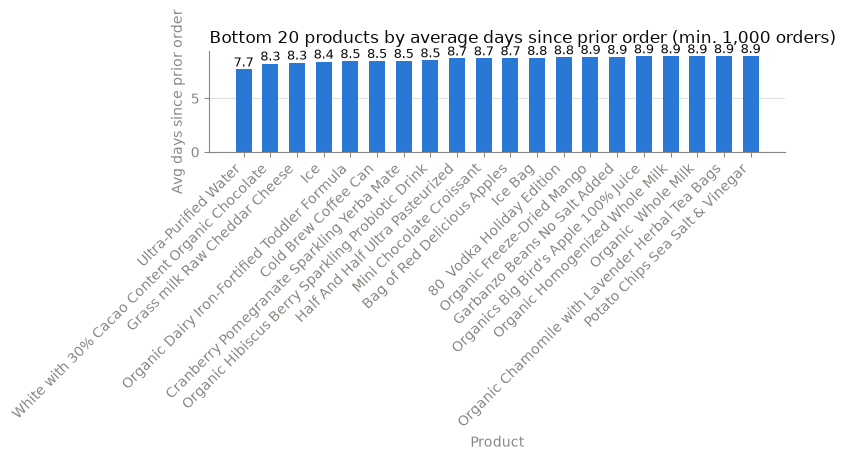

,product_name,item_count,avg_days_since_prior
0,Ultra-Purified Water,1524,7.695951
1,White with 30% Cacao Content Organic Chocolate,1439,8.252555
2,Grass milk Raw Cheddar Cheese,1509,8.335203
3,Ice,2803,8.436636
4,Organic Dairy Iron-Fortified Toddler Formula,1036,8.471183
5,Cold Brew Coffee Can,1039,8.488166
6,Cranberry Pomegranate Sparkling Yerba Mate,1178,8.488928
7,Organic Hibiscus Berry Sparkling Probiotic Drink,1165,8.549091
8,Half And Half Ultra Pasteurized,2995,8.721221
9,Mini Chocolate Croissant,1038,8.730348


In [42]:
product_days_since_prior_bottom20 = db.sql("""
    select
        p.product_name,
        count(*) as item_count,
        avg(f.days_since_prior_order) as avg_days_since_prior
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    group by p.product_name
    having count(*) >= 1000
    order by avg_days_since_prior asc
    limit 20
""").df()

bar_chart(
    product_days_since_prior_bottom20["product_name"],
    product_days_since_prior_bottom20["avg_days_since_prior"],
    color=BLUE,
    title="Bottom 20 products by average days since prior order (min. 1,000 orders)",
    xlabel="Product",
    ylabel="Avg days since prior order",
    value_fmt="{:,.1f}",
    rotate_x=45,
)

product_days_since_prior_bottom20

**Top 20 by average days since prior order** (same `>= 1,000` order floor and same cut to 20, for the same reasons as the bottom-20 chart above) — the other end of the range: products whose buyers are on the longest repurchase cycle. Together with the bottom 20 above, these two cells span the true min and max of `avg_days_since_prior_order` across all qualifying products (the "top 20 most-ordered products" chart earlier only covers the popularity-weighted middle of that range, ~9.9–12.3 days, not its extremes).

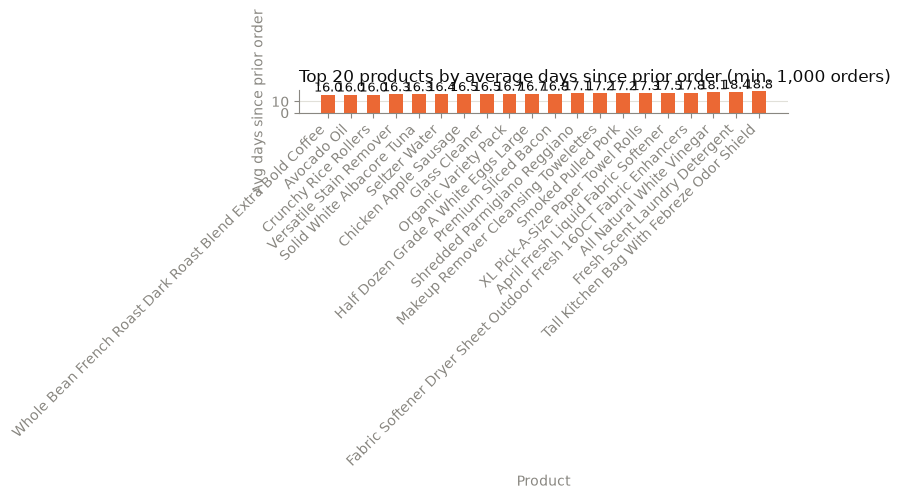

,product_name,item_count,avg_days_since_prior
19,Whole Bean French Roast Dark Roast Blend Extra...,1044,16.005214
18,Avocado Oil,1919,16.023125
17,Crunchy Rice Rollers,1784,16.040000
16,Versatile Stain Remover,1585,16.272360
15,Solid White Albacore Tuna,1743,16.288328
14,Seltzer Water,1982,16.416849
13,Chicken Apple Sausage,3705,16.478861
12,Glass Cleaner,1833,16.527348
11,Organic Variety Pack,3291,16.699869
10,Half Dozen Grade A White Eggs Large,1107,16.715431


In [43]:
product_days_since_prior_top20 = db.sql("""
    select
        p.product_name,
        count(*) as item_count,
        avg(f.days_since_prior_order) as avg_days_since_prior
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    group by p.product_name
    having count(*) >= 1000
    order by avg_days_since_prior desc
    limit 20
""").df().sort_values("avg_days_since_prior")

bar_chart(
    product_days_since_prior_top20["product_name"],
    product_days_since_prior_top20["avg_days_since_prior"],
    color=ORANGE,
    title="Top 20 products by average days since prior order (min. 1,000 orders)",
    xlabel="Product",
    ylabel="Avg days since prior order",
    value_fmt="{:,.1f}",
    rotate_x=45,
)

product_days_since_prior_top20

### 9. Top 5 and bottom 5 products by % reordered

`% reordered = reorder_count / total_count`, restricted to products with at least 1,000 orders (same floor and reasoning as section 8) so the ranking isn't dominated by low-volume products where one or two reorders swing the rate to 0% or 100%. Kept to 5 a side rather than 10 (unlike the add-to-cart product view) since the extremes alone already tell the story — milk/produce staples at ~85% vs. spices at ~5–8% — and widening the cut would mostly add mid-pack products without changing that takeaway.

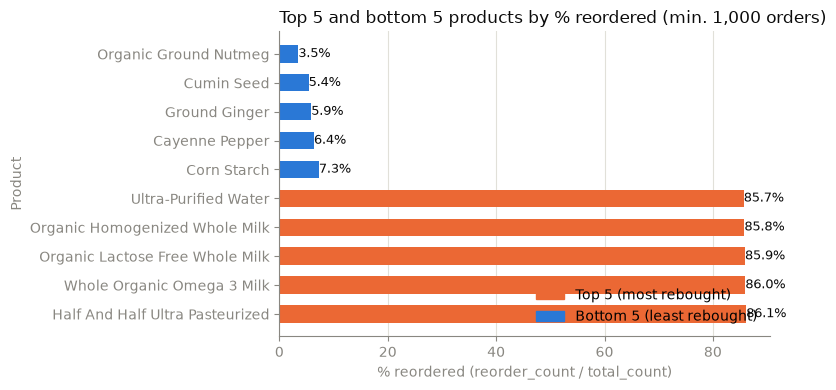

,product_name,total_count,reorder_count,reorder_rate_pct,group
5214,Organic Ground Nutmeg,1088,38.0,3.492647,Bottom 5 (least rebought)
3627,Cumin Seed,1055,57.0,5.402844,Bottom 5 (least rebought)
1750,Ground Ginger,1785,105.0,5.882353,Bottom 5 (least rebought)
1503,Cayenne Pepper,1755,112.0,6.381766,Bottom 5 (least rebought)
606,Corn Starch,1921,140.0,7.287871,Bottom 5 (least rebought)
3090,Ultra-Purified Water,1524,1306.0,85.695538,Top 5 (most rebought)
864,Organic Homogenized Whole Milk,4095,3514.0,85.811966,Top 5 (most rebought)
2787,Organic Lactose Free Whole Milk,8742,7511.0,85.918554,Top 5 (most rebought)
1407,Whole Organic Omega 3 Milk,9410,8091.0,85.982997,Top 5 (most rebought)
717,Half And Half Ultra Pasteurized,2995,2580.0,86.143573,Top 5 (most rebought)


In [44]:
product_reorder_rate = db.sql("""
    select
        p.product_name,
        count(*) as total_count,
        sum(f.reordered) as reorder_count,
        avg(f.reordered) as reorder_rate
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    group by p.product_name
    having count(*) >= 1000
""").df()

top5_reordered = product_reorder_rate.nlargest(5, "reorder_rate").copy()
top5_reordered["group"] = "Top 5 (most rebought)"
bottom5_reordered = product_reorder_rate.nsmallest(5, "reorder_rate").copy()
bottom5_reordered["group"] = "Bottom 5 (least rebought)"

reorder_rate_extremes = pd.concat([top5_reordered, bottom5_reordered]).sort_values("reorder_rate")
reorder_rate_extremes["reorder_rate_pct"] = reorder_rate_extremes["reorder_rate"] * 100
reorder_rate_colors = [
    ORANGE if g.startswith("Top") else BLUE for g in reorder_rate_extremes["group"]
]

diverging_bar_chart(
    reorder_rate_extremes["product_name"],
    reorder_rate_extremes["reorder_rate_pct"],
    reorder_rate_colors,
    legend={"Top 5 (most rebought)": ORANGE, "Bottom 5 (least rebought)": BLUE},
    title="Top 5 and bottom 5 products by % reordered (min. 1,000 orders)",
    xlabel="% reordered (reorder_count / total_count)",
    ylabel="Product",
    value_fmt="{:.1f}%",
)

reorder_rate_extremes[["product_name", "total_count", "reorder_count", "reorder_rate_pct", "group"]]